# Fragrance shelf-life stability - Root cause analysis

**Objective 1:** **Root Cause Analysis** - Identify which process parameters and conditions explain the anormal reduced shelf-life stability. Determine whether specific reactors, plants, or operating regimes are responsible.

To achieve this objective, I'll start with EDA (Exploratory Data Analysis) to understand the data distribution, identify patterns, and detect any anomalies.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

raw_data = pd.read_csv('data_set.csv')
print('Data Shape:', raw_data.shape)
raw_data.head(10)

Data Shape: (259200, 16)


,batch_id,event_timestamp,plant_location,plant_country,production_line_id,temp_value,temp_unit,vessel_pressure_bar,refractive_index,density_g_cm3,ph_level,mixing_torque_nm,mass_flow_rate_kg_h,stability_months,purity_grade,oxidation_risk_flag
0,BATCH-2023-000001,2023-06-02 03:05:00,Plant-05,Country-05,Fragrance-Synthesis-Reactor-02,82.3319,C,2.46575,1.465316,0.858032,NaN,11.97486,492.9606,21.090538,Industrial Grade,False
1,BATCH-2023-000002,2023-04-12 02:47:30,Plant-05,Country-05,Fragrance-Synthesis-Reactor-04,91.7391,C,2.24107,1.455938,0.876435,5.79598,11.85726,449.9237,21.202418,Industrial Grade,False
2,BATCH-2023-000003,2023-06-03 11:35:30,Plant-03,Country-03,Fragrance-Synthesis-Reactor-07,85.0281,C,2.34404,1.468787,0.848555,5.31299,12.02680,437.1050,22.515180,Industrial Grade,False
3,BATCH-2023-000004,2023-05-11 02:43:00,Plant-04,Country-04,Fragrance-Synthesis-Reactor-05,88.5994,C,2.10548,1.447880,0.871153,5.44103,11.67030,439.3516,19.843445,Technical Grade,True
4,BATCH-2023-000005,2023-05-19 13:12:30,Plant-01,Country-01,Fragrance-Synthesis-Reactor-01,82.4168,C,2.16206,NaN,0.840569,5.06367,12.24158,447.2072,24.464046,Industrial Grade,False
5,BATCH-2023-000006,2023-05-24 06:33:30,Plant-05,Country-05,Fragrance-Synthesis-Reactor-01,80.8814,C,2.05621,1.477078,0.843090,5.87797,12.26104,NaN,21.996324,Industrial Grade,False
6,BATCH-2023-000007,2023-05-13 09:22:30,Plant-05,Country-05,Fragrance-Synthesis-Reactor-06,NaN,NaN,2.05622,1.456565,0.860863,5.94286,12.09444,NaN,20.168556,Industrial Grade,True
7,BATCH-2023-000008,2023-04-04 12:14:30,Plant-01,Country-01,Fragrance-Synthesis-Reactor-09,NaN,NaN,2.08380,1.468761,0.867817,5.20713,11.77220,464.2447,19.958718,Technical Grade,True
8,BATCH-2023-000009,2023-06-25 00:44:00,Plant-05,Country-05,Fragrance-Synthesis-Reactor-05,88.7724,C,2.51944,1.446591,NaN,5.92075,11.90492,409.9678,18.814563,Technical Grade,True
9,BATCH-2023-000010,2023-06-16 05:37:30,Plant-05,Country-05,Fragrance-Synthesis-Reactor-06,91.4397,C,2.21362,1.475665,0.843763,5.14246,11.86474,461.4773,19.713183,Technical Grade,True


## 1. Structure of the data

In [24]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 259200 entries, BATCH-2023-000001 to BATCH-2023-259200
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   event_timestamp      259200 non-null  object 
 1   plant_location       259200 non-null  object 
 2   plant_country        259200 non-null  object 
 3   production_line_id   259200 non-null  object 
 4   temp_value           236030 non-null  float64
 5   temp_unit            236030 non-null  object 
 6   vessel_pressure_bar  236225 non-null  float64
 7   refractive_index     236229 non-null  float64
 8   density_g_cm3        236157 non-null  float64
 9   ph_level             236263 non-null  float64
 10  mixing_torque_nm     236320 non-null  float64
 11  mass_flow_rate_kg_h  236038 non-null  float64
 12  stability_months     259200 non-null  float64
 13  purity_grade         259200 non-null  object 
 14  oxidation_risk_flag  259200 non-null  bool   


In [3]:
raw_data.describe(include='all')

,batch_id,event_timestamp,plant_location,plant_country,production_line_id,temp_value,temp_unit,vessel_pressure_bar,refractive_index,density_g_cm3,ph_level,mixing_torque_nm,mass_flow_rate_kg_h,stability_months,purity_grade,oxidation_risk_flag
count,259200,259200,259200,259200,259200,236030.000000,236030,236225.000000,236229.000000,236157.000000,236263.000000,236320.000000,236038.000000,259200.000000,259200,259200
unique,259200,154112,5,5,10,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2
top,BATCH-2023-000001,"May 18, 2023",Plant-01,Country-01,Fragrance-Synthesis-Reactor-05,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Industrial Grade,False
freq,1,186,70644,70644,36951,NaN,234524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172452,140183
mean,NaN,NaN,NaN,NaN,NaN,86.879507,NaN,2.300345,1.460660,2.890029,5.522631,11.941048,453.558692,21.531590,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,10.854512,NaN,0.232456,0.011674,41.712658,0.500053,0.392478,36.897379,2.045193,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,78.955600,NaN,-1.000000,1.437219,0.837224,4.945060,10.035246,383.250500,18.015190,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,82.802325,NaN,2.159800,1.450678,0.850017,5.254690,11.709900,421.858325,19.911618,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,86.000000,NaN,2.307150,1.460645,0.860061,5.502770,11.974240,453.350100,21.229013,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,89.220300,NaN,2.454450,1.470644,0.870153,5.754930,12.238880,485.355525,22.912059,NaN,NaN


Note: The datatime has been converted to datetime format since in the dataset is a mix of datetime and date without a timestamp.

In [27]:
#Unique batches, duplicates, time span
print('Duplicated rows:', raw_data.duplicated().sum())
print('Duplicated batch ids:', raw_data['batch_id'].duplicated().sum())

raw_data['event_timestamp'] = pd.to_datetime(raw_data['event_timestamp'], format='mixed', dayfirst=True)
print('First record:', raw_data['event_timestamp'].min())
print('Last record:', raw_data['event_timestamp'].max())
print('Total duration:', raw_data['event_timestamp'].max() - raw_data['event_timestamp'].min())

print('\nUnique countries:', raw_data['plant_country'].nunique())
print('Unique locations:', raw_data['plant_location'].nunique())
print('Unique reactors:', raw_data['production_line_id'].nunique())

Duplicated rows: 0
Duplicated batch ids: 0
First record: 2023-04-01 00:00:00
Last record: 2023-06-29 23:59:30
Total duration: 89 days 23:59:30

Unique countries: 5
Unique locations: 5
Unique reactors: 10


In [5]:
#Checking if the reactors are tied to a plant or if all plants use all reactors
print(pd.crosstab(raw_data['production_line_id'], raw_data['plant_country']))

plant_country                   Country-01  Country-02  Country-03  \
production_line_id                                                   
Fragrance-Synthesis-Reactor-01        5598        6180        5753   
Fragrance-Synthesis-Reactor-02        6140        6341        6425   
Fragrance-Synthesis-Reactor-03        6122        7296        6486   
Fragrance-Synthesis-Reactor-04        7070        7459        7116   
Fragrance-Synthesis-Reactor-05        6950        7864        7537   
Fragrance-Synthesis-Reactor-06        7015           0        7813   
Fragrance-Synthesis-Reactor-07        7658           0        7693   
Fragrance-Synthesis-Reactor-08        7840           0           0   
Fragrance-Synthesis-Reactor-09        8104           0           0   
Fragrance-Synthesis-Reactor-10        8147           0           0   

plant_country                   Country-04  Country-05  
production_line_id                                      
Fragrance-Synthesis-Reactor-01        5771   

`plant_location` and `plant_country` carry the same information (one plant per country), so one of them can be dropped.

The reactor ids are not physical machines: every plant has reactors 01 to 05, Plant-01 has all ten, Plant-04 has 01 to 08. Any reactor effect therefore has to be checked per plant.

## 2. Missing values and temperature units

In [6]:
print('Missing values per column:')
print(raw_data.isna().sum())

print('\nTemperature units:')
print(raw_data['temp_unit'].value_counts(dropna=False))

Missing values per column:
batch_id                   0
event_timestamp            0
plant_location             0
plant_country              0
production_line_id         0
temp_value             23170
temp_unit              23170
vessel_pressure_bar    22975
refractive_index       22971
density_g_cm3          23043
ph_level               22937
mixing_torque_nm       22880
mass_flow_rate_kg_h    23162
stability_months           0
purity_grade               0
oxidation_risk_flag        0
dtype: int64

Temperature units:
temp_unit
C      234524
NaN     23170
F        1506
Name: count, dtype: int64


In [7]:
#Looking at the Fahrenheit rows before converting
f_rows = raw_data[raw_data['temp_unit'] == 'F']
print('Fahrenheit rows - value range:')
print(f_rows['temp_value'].describe())
print('\nFahrenheit rows by plant:')
print(f_rows['plant_country'].value_counts())

#Converting everything to Celsius into a new column, keeping the original
raw_data['reaction_temperature_celsius'] = raw_data['temp_value']
is_f = raw_data['temp_unit'] == 'F'
raw_data.loc[is_f, 'reaction_temperature_celsius'] = (raw_data.loc[is_f, 'temp_value'] - 32) * 5 / 9

Fahrenheit rows - value range:
count    1506.000000
mean      189.051195
std        25.860875
min       174.677900
25%       180.531590
50%       186.386900
75%       192.236000
max       410.000000
Name: temp_value, dtype: float64

Fahrenheit rows by plant:
plant_country
Country-04    1506
Name: count, dtype: int64


In [8]:
#Is the missing data concentrated in a plant or reactor?
sensor_cols = ['reaction_temperature_celsius', 'vessel_pressure_bar', 'refractive_index',
               'density_g_cm3', 'ph_level', 'mixing_torque_nm', 'mass_flow_rate_kg_h']

print('Missing data % by plant:')
print(raw_data.groupby('plant_country')[sensor_cols].apply(lambda x: x.isnull().mean() * 100).round(2))
print('\nMissing data % by reactor:')
print(raw_data.groupby('production_line_id')[sensor_cols].apply(lambda x: x.isnull().mean() * 100).round(2))

Missing data % by plant:
               reaction_temperature_celsius  vessel_pressure_bar  \
plant_country                                                      
Country-01                             9.08                 9.04   
Country-02                             9.08                 8.63   
Country-03                             8.75                 8.86   
Country-04                             8.93                 8.86   
Country-05                             8.83                 8.78   

               refractive_index  density_g_cm3  ph_level  mixing_torque_nm  \
plant_country                                                                
Country-01                 8.99           8.99      8.69              8.88   
Country-02                 8.88           8.94      8.76              8.84   
Country-03                 8.79           8.74      8.78              8.84   
Country-04                 8.88           8.78      8.97              8.83   
Country-05                 8.7

Around 9% of each sensor is missing, spread evenly over plants and reactors, so the missing values look random. About 1,500 temperature readings were logged in Fahrenheit; they were converted to Celsius.

## 3. Out-of-range values

In [9]:
normal_ranges = {
    'reaction_temperature_celsius': (75, 100),
    'vessel_pressure_bar': (2, 3),
    'refractive_index': (1.43, 1.49),
    'density_g_cm3': (0.80, 0.90),
    'ph_level': (5.0, 6.0),
    'mixing_torque_nm': (9, 12.5),
    'mass_flow_rate_kg_h': (380, 520),
    'stability_months': (18, 30)
}
cannot_be_negative = ['vessel_pressure_bar', 'mixing_torque_nm', 'mass_flow_rate_kg_h']

overall_outlier_mask = pd.Series(False, index=raw_data.index)
outlier_details = []

for col, (min_val, max_val) in normal_ranges.items():
    column_mask = raw_data[col].notnull() & ((raw_data[col] < min_val) | (raw_data[col] > max_val))
    overall_outlier_mask = overall_outlier_mask | column_mask

    negative_count = (raw_data[col] < 0).sum() if col in cannot_be_negative else 0
    below_count = ((raw_data[col] >= 0) & (raw_data[col] < min_val)).sum() if col in cannot_be_negative else (raw_data[col] < min_val).sum()
    above_count = (raw_data[col] > max_val).sum()

    outlier_details.append({
        'Parameter': col,
        'Negative': negative_count,
        'Below Min': below_count,
        'Above Max': above_count,
        'Total Outliers': negative_count + below_count + above_count
    })

outliers_summary = pd.DataFrame(outlier_details)
print(outliers_summary.to_string(index=False))
print(f'\nRows with at least one out-of-range value: {overall_outlier_mask.sum()}')

                   Parameter  Negative  Below Min  Above Max  Total Outliers
reaction_temperature_celsius         0          0        526             526
         vessel_pressure_bar       544        509          0            1053
            refractive_index         0          0          0               0
               density_g_cm3         0          0        558             558
                    ph_level         0       3396       4785            8181
            mixing_torque_nm         0          0       3853            3853
         mass_flow_rate_kg_h         0          0        456             456
            stability_months         0          0          0               0

Rows with at least one out-of-range value: 14342


In [10]:
#Are the out-of-range values real drift or repeated fixed values?
for col, (min_val, max_val) in normal_ranges.items():
    out_mask = raw_data[col].notnull() & ((raw_data[col] < min_val) | (raw_data[col] > max_val))
    if out_mask.sum() > 0:
        print(f'\n{col}: {out_mask.sum()} out of range values, most common:')
        print(raw_data.loc[out_mask, col].round(2).value_counts().head(5))


reaction_temperature_celsius: 526 out of range values, most common:
reaction_temperature_celsius
210.0    526
Name: count, dtype: int64

vessel_pressure_bar: 1053 out of range values, most common:
vessel_pressure_bar
-1.00    544
 2.00    277
 1.99    232
Name: count, dtype: int64

density_g_cm3: 558 out of range values, most common:
density_g_cm3
860.0    558
Name: count, dtype: int64

ph_level: 8181 out of range values, most common:
ph_level
4.99    1038
6.01    1022
4.98     829
6.02     806
6.03     757
Name: count, dtype: int64

mixing_torque_nm: 3853 out of range values, most common:
mixing_torque_nm
12.51    934
12.52    863
12.53    717
12.50    505
12.54    456
Name: count, dtype: int64

mass_flow_rate_kg_h: 456 out of range values, most common:
mass_flow_rate_kg_h
520.50    13
520.38    10
520.32     9
520.01     7
520.04     7
Name: count, dtype: int64


Two different things are mixed in the out-of-range counts:

- **Fixed sensor fault codes**: 210 for temperature, -1 for pressure, 860 for density, 14 for pH. Each appears as one constant value, ~530-560 times. These are not real measurements.
- **Normal spread slightly past the spec limits**: pH 4.98-6.03, torque 12.50-12.54, flow 520.x, pressure 1.99. The real distributions are a bit wider than the round numbers in the spec. These are not outliers and will be kept for later training the model.

## 4. Distributions

Skewness:
reaction_temperature_celsius    12.734
vessel_pressure_bar             -6.538
refractive_index                 0.001
density_g_cm3                   20.499
ph_level                        11.160
mixing_torque_nm                -1.271
mass_flow_rate_kg_h              0.006
stability_months                 0.547
dtype: float64


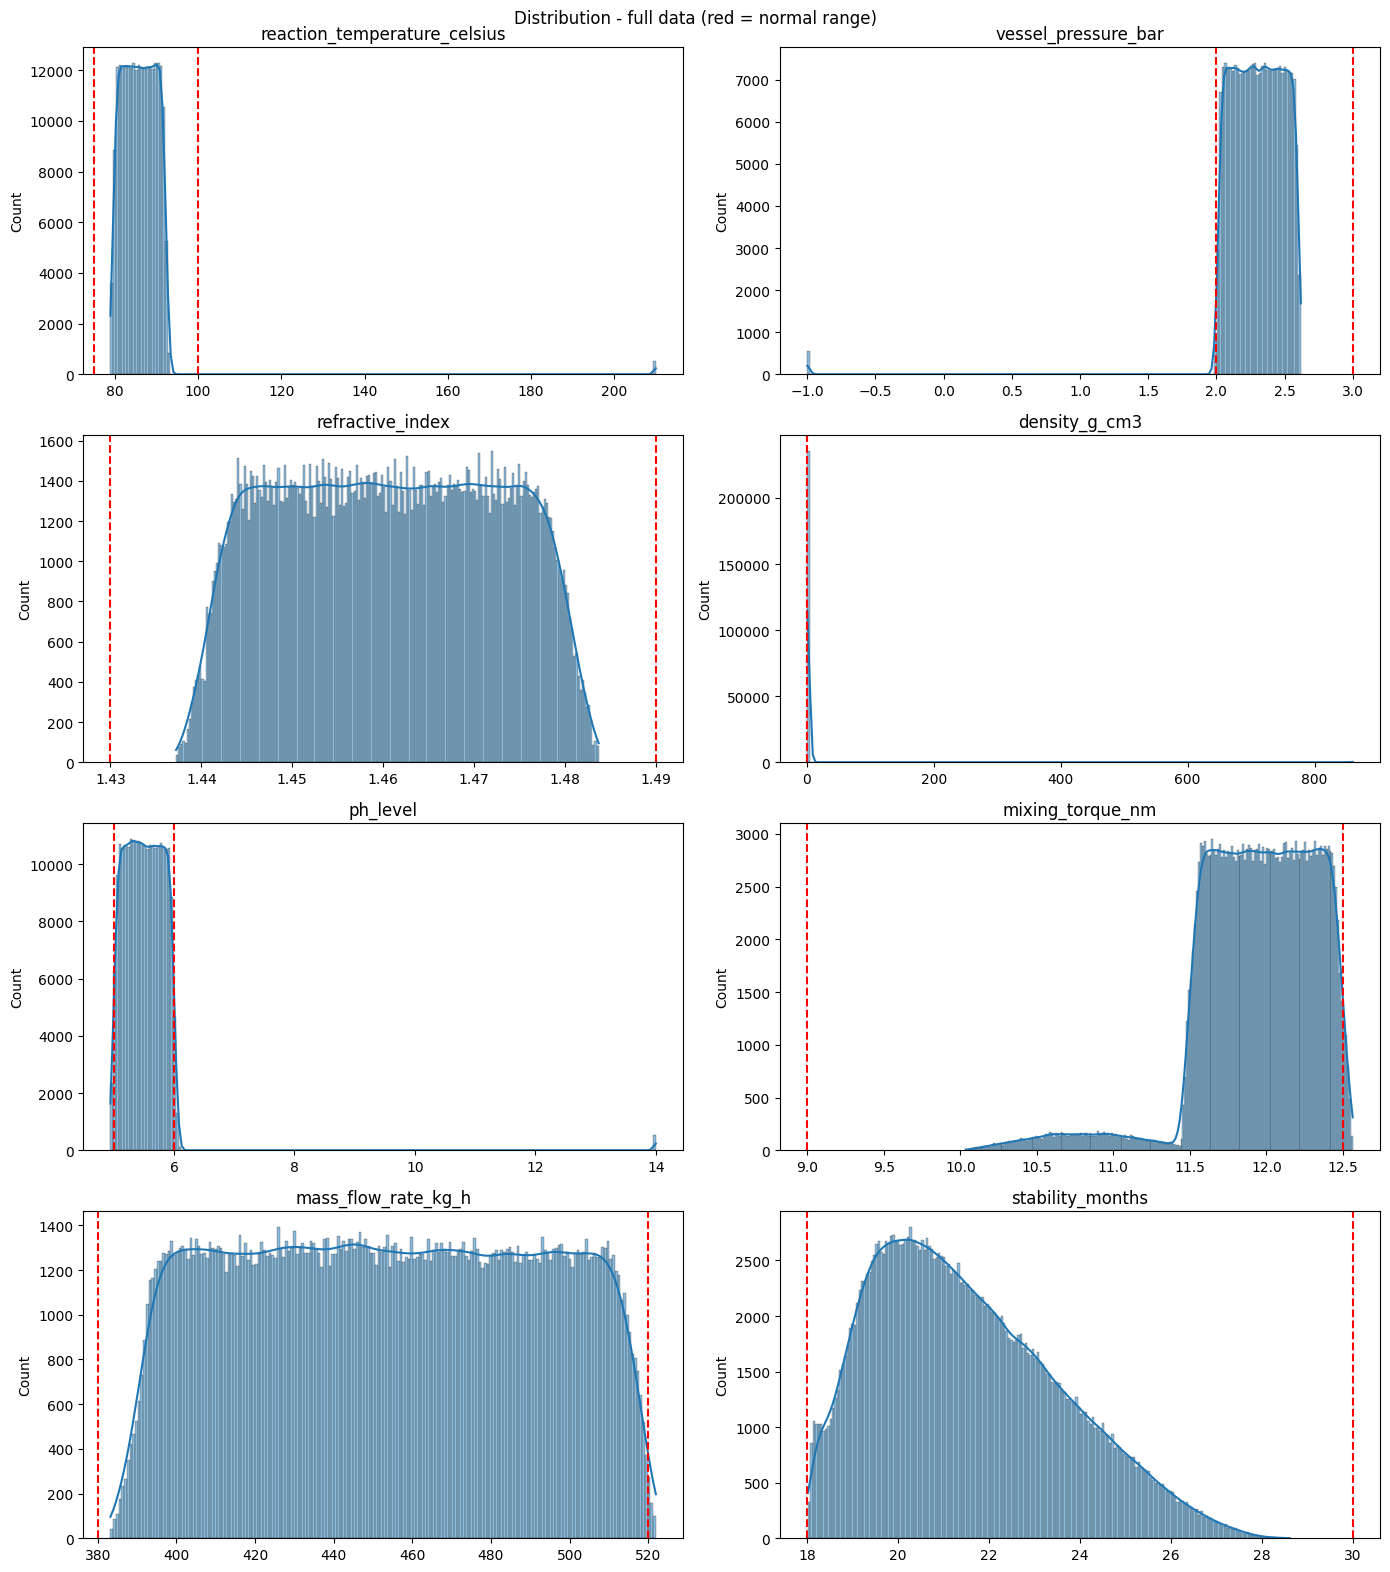

In [11]:
num_cols = list(normal_ranges.keys())
print('Skewness:')
print(raw_data[num_cols].skew().round(3))

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    min_val, max_val = normal_ranges[col]
    sns.histplot(raw_data[col].dropna(), bins=200, kde=True, ax=axes[i])
    axes[i].axvline(min_val, color='red', linestyle='--')
    axes[i].axvline(max_val, color='red', linestyle='--')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Distribution - full data (red = normal range)')
plt.tight_layout()
plt.show()

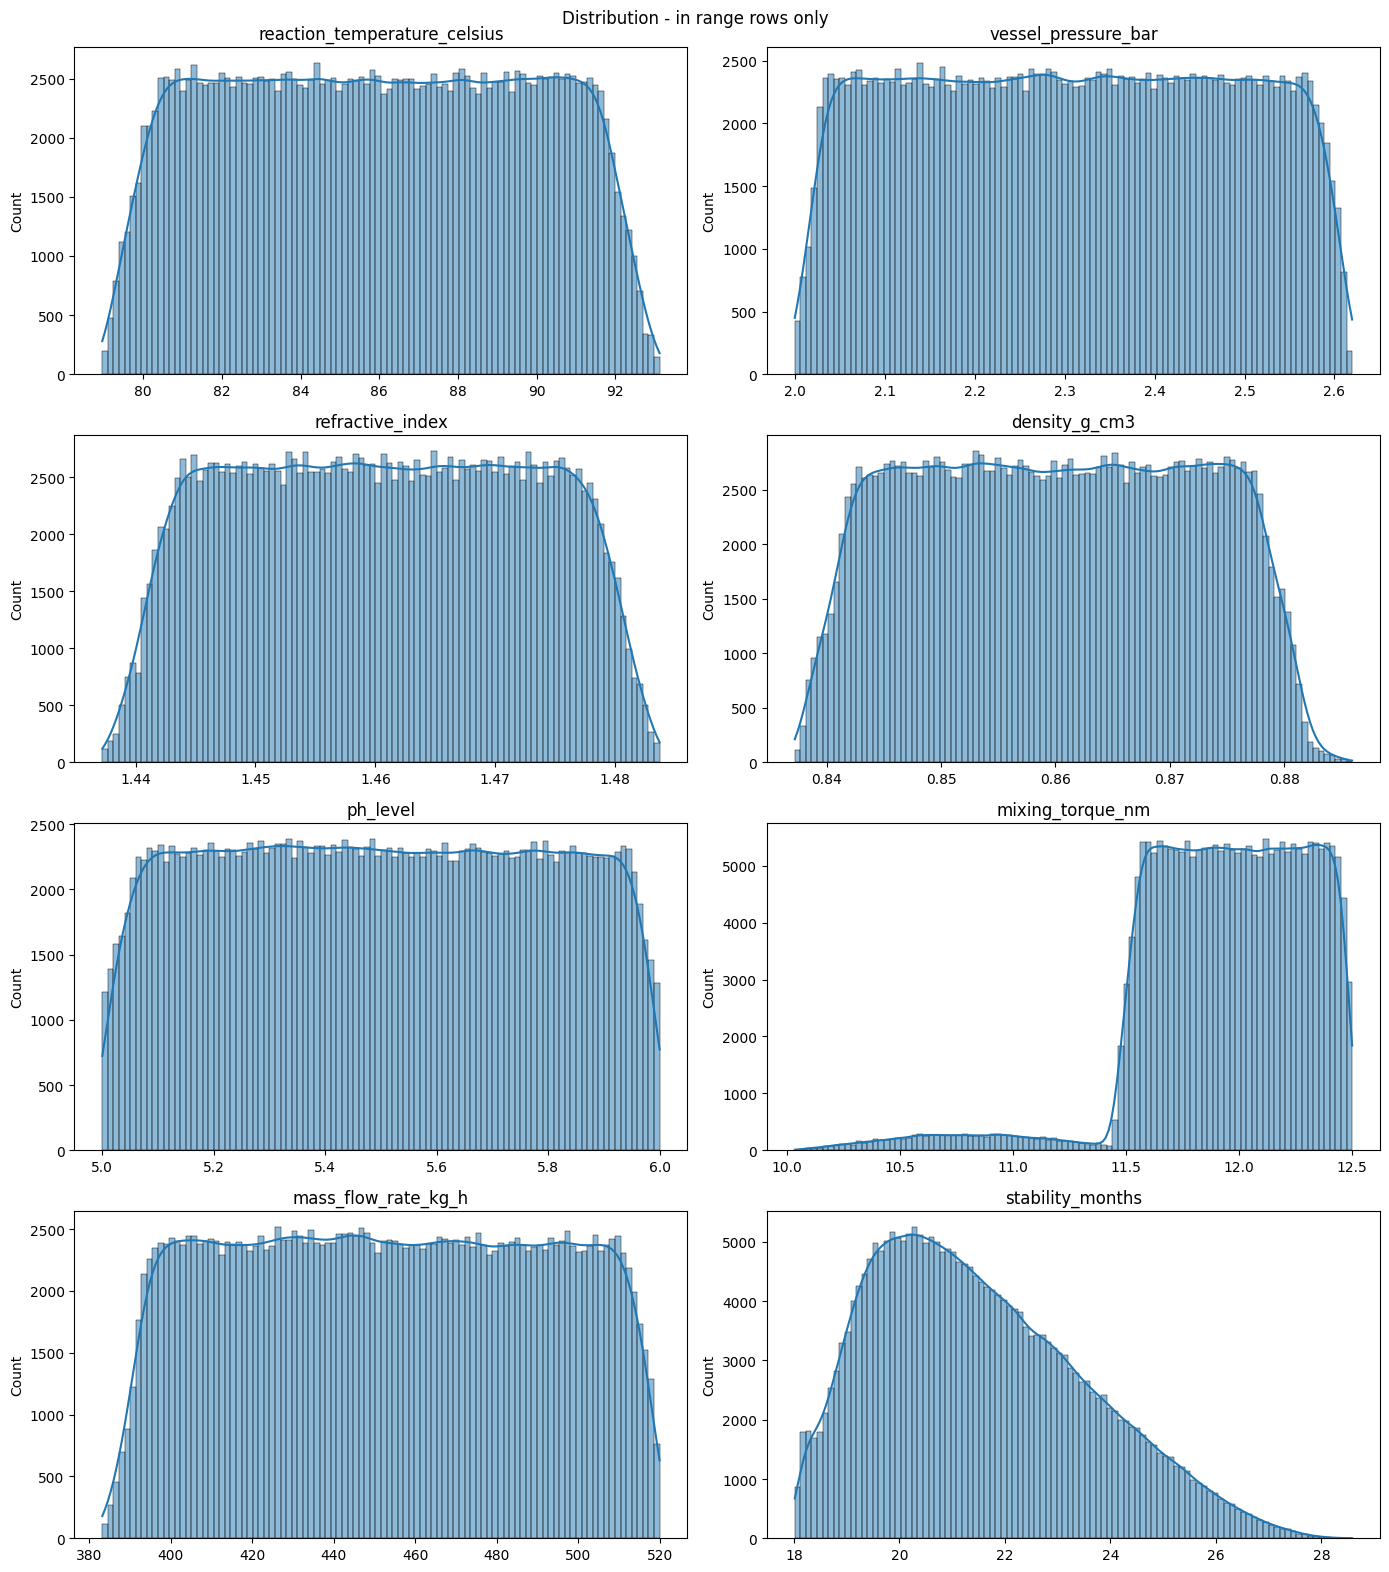

In [12]:
#Same plots without the out-of-range rows, to see the shape of the bulk
in_range_data = raw_data[~overall_outlier_mask]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(in_range_data[col].dropna(), bins=100, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Distribution - in range rows only')
plt.tight_layout()
plt.show()

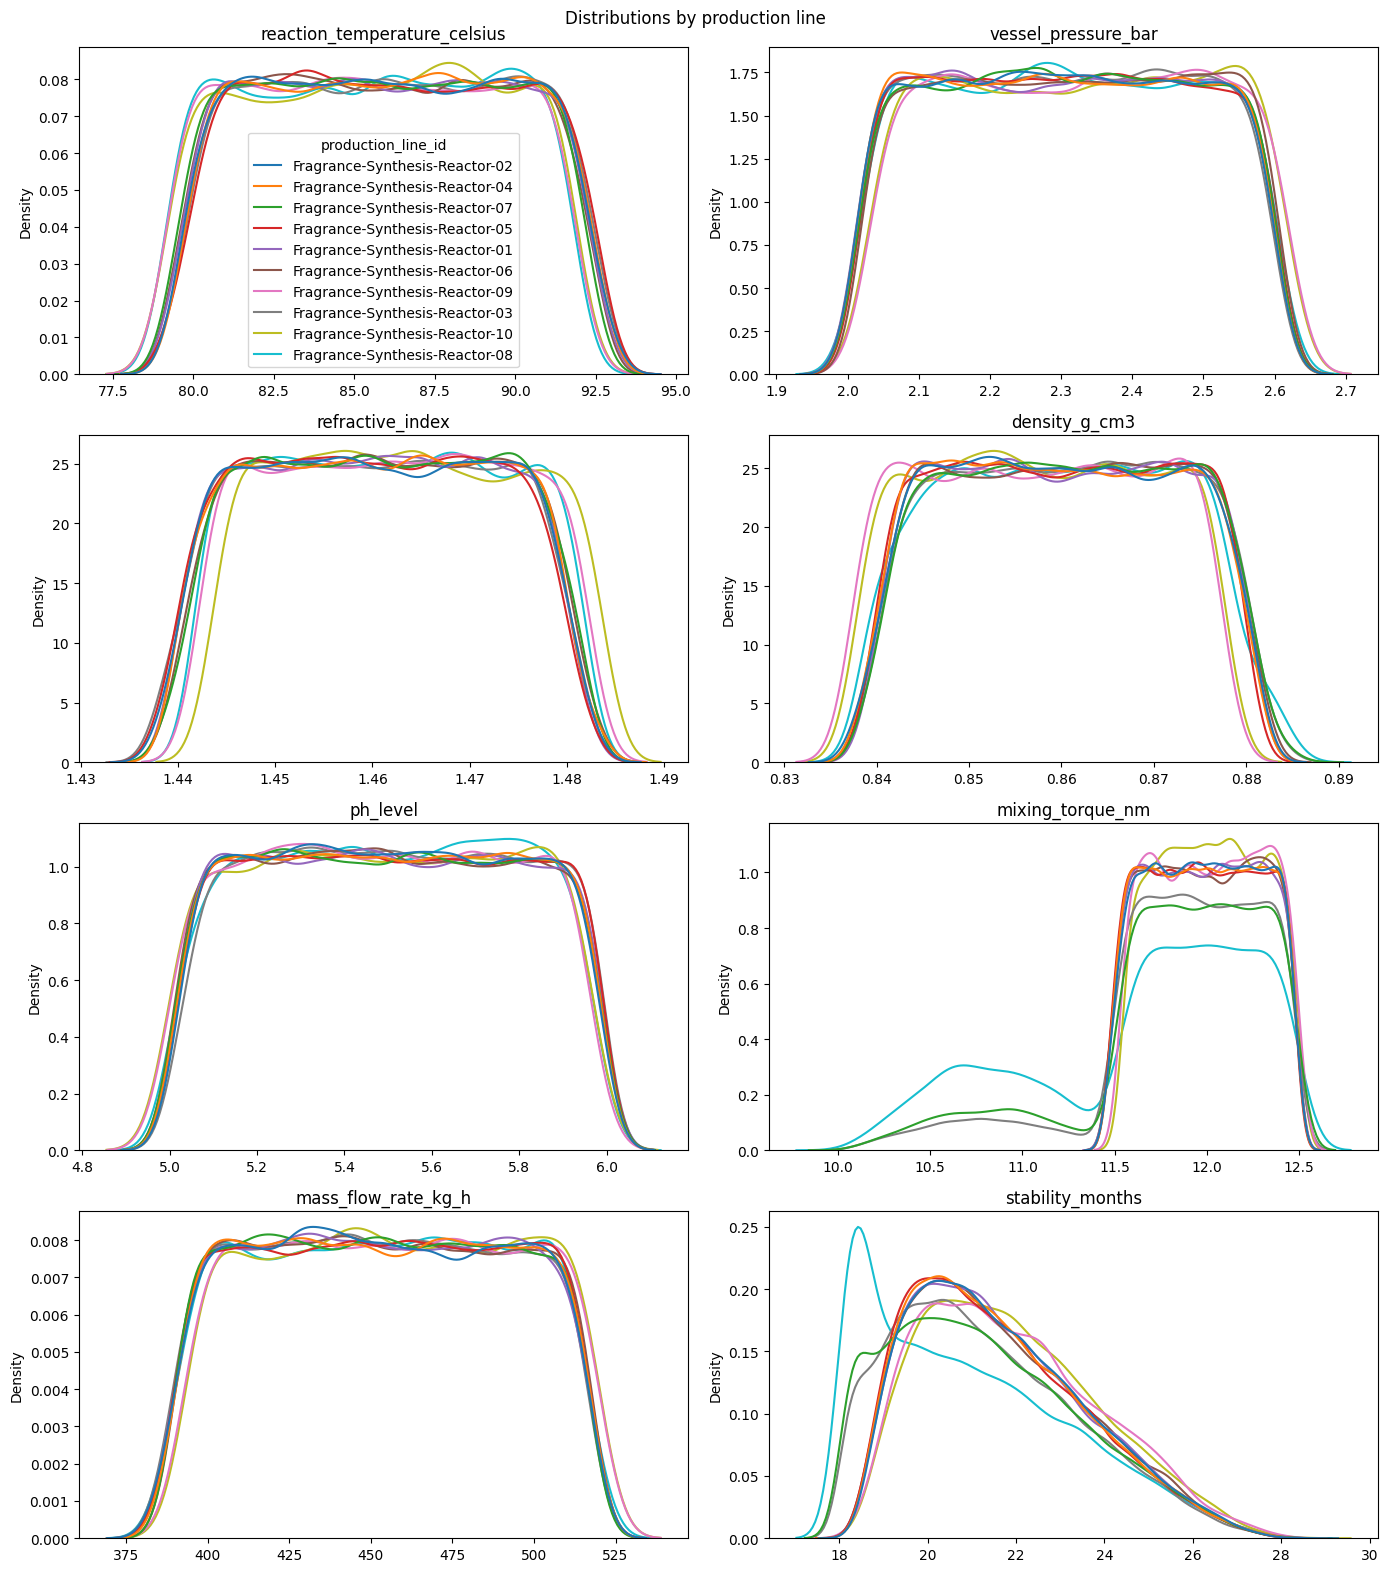

In [13]:
#Checking if the distributions differ by reactor
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(data=in_range_data, x=col, hue='production_line_id',
                common_norm=False, ax=axes[i], legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Distributions by production line')
plt.tight_layout()
plt.show()

All sensors are uniform inside their range and identical across reactors, except **mixing torque**, which is bimodal: a main block at 11.5-12.5 N·m and a second, smaller population at 10-11.4 N·m. Only reactors 03, 07 and 08 have the second population, and the same three reactors have an extra bump at low stability.

## 5. Mixing torque: two operating regimes

In [14]:
#Flagging the low-torque population. 11.4 is the gap between the two modes in the histogram
raw_data['low_torque'] = raw_data['mixing_torque_nm'] < 11.4

print('Share of low-torque batches by reactor:')
print(raw_data.groupby('production_line_id')['low_torque'].mean().round(3))
print('\nShare of low-torque batches by plant:')
print(raw_data.groupby('plant_country')['low_torque'].mean().round(3))
print('\nStability by torque population:')
print(raw_data.groupby('low_torque')['stability_months'].describe().round(2))

Share of low-torque batches by reactor:
production_line_id
Fragrance-Synthesis-Reactor-01    0.000
Fragrance-Synthesis-Reactor-02    0.000
Fragrance-Synthesis-Reactor-03    0.101
Fragrance-Synthesis-Reactor-04    0.000
Fragrance-Synthesis-Reactor-05    0.000
Fragrance-Synthesis-Reactor-06    0.000
Fragrance-Synthesis-Reactor-07    0.129
Fragrance-Synthesis-Reactor-08    0.261
Fragrance-Synthesis-Reactor-09    0.000
Fragrance-Synthesis-Reactor-10    0.000
Name: low_torque, dtype: float64

Share of low-torque batches by plant:
plant_country
Country-01    0.000
Country-02    0.000
Country-03    0.000
Country-04    0.206
Country-05    0.000
Name: low_torque, dtype: float64

Stability by torque population:
               count   mean   std    min    25%    50%    75%    max
low_torque                                                          
False       247716.0  21.67  1.98  18.03  20.08  21.35  23.00  28.61
True         11484.0  18.56  0.50  18.02  18.22  18.41  18.73  22.65


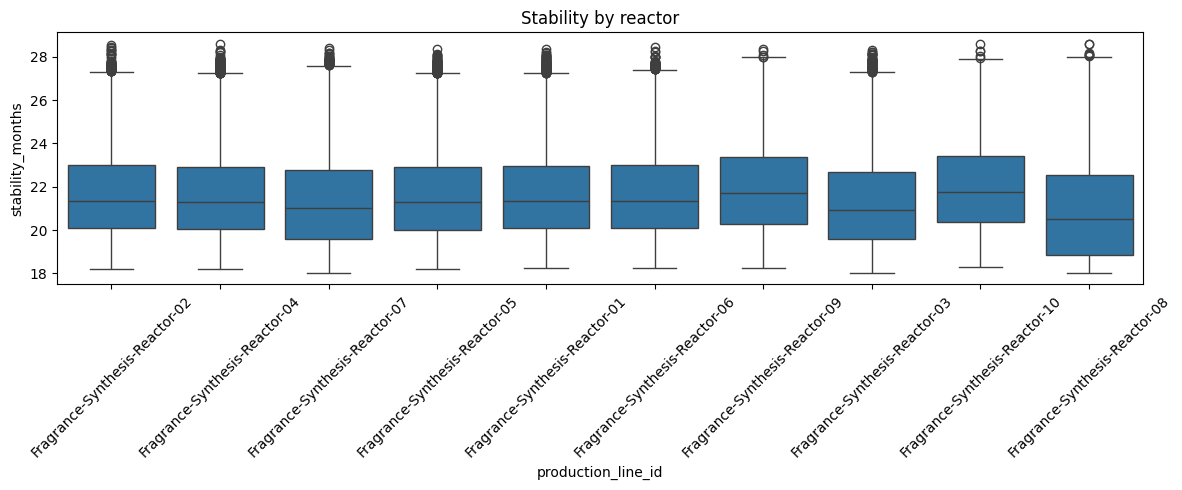

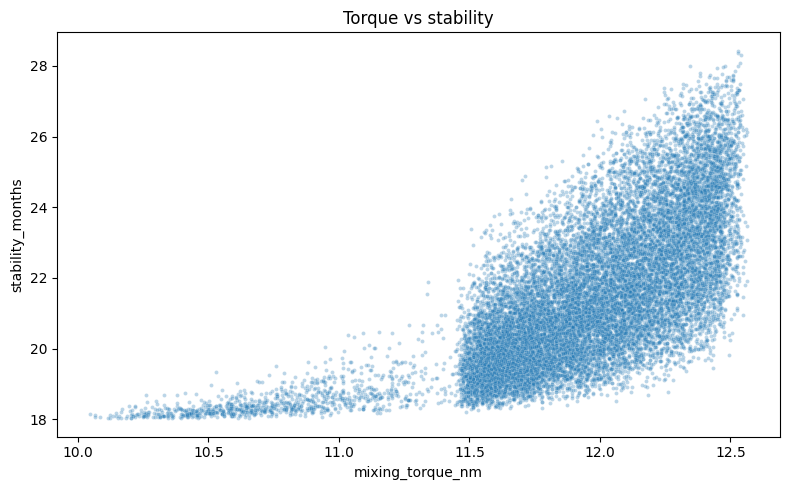

In [15]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=raw_data, x='production_line_id', y='stability_months')
plt.xticks(rotation=45)
plt.title('Stability by reactor')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=raw_data.sample(20000, random_state=42),
                x='mixing_torque_nm', y='stability_months', alpha=0.3, s=8)
plt.title('Torque vs stability')
plt.tight_layout()
plt.show()

Correlation with stability_months:
stability_months                1.000
mixing_torque_nm                0.684
refractive_index                0.129
mass_flow_rate_kg_h            -0.003
vessel_pressure_bar            -0.013
ph_level                       -0.014
density_g_cm3                  -0.040
reaction_temperature_celsius   -0.387
Name: stability_months, dtype: float64


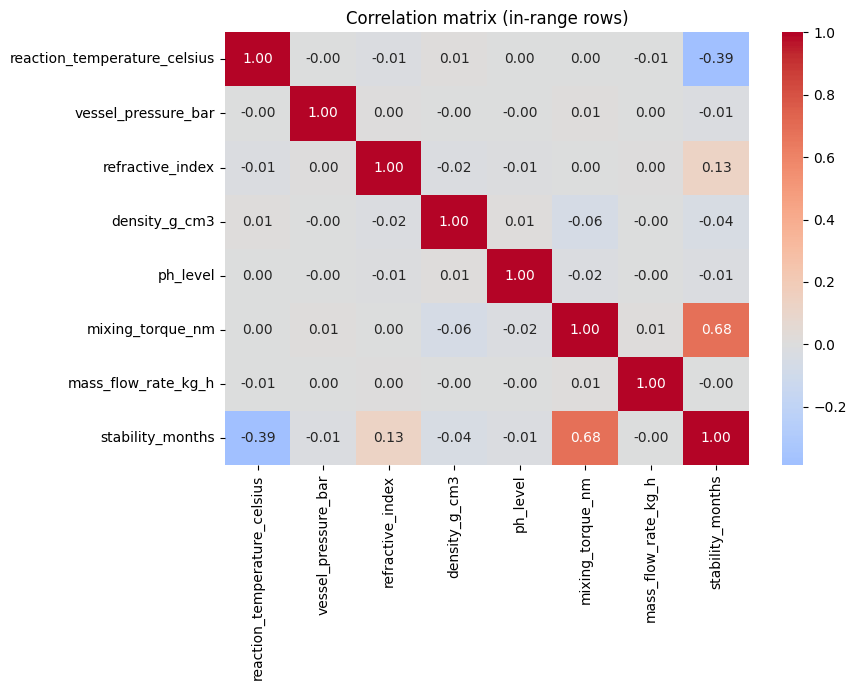

In [16]:
#Correlation between sensors and stability (in-range rows so the fault codes do not distort it)
corr = in_range_data[num_cols].corr()
print('Correlation with stability_months:')
print(corr['stability_months'].sort_values(ascending=False).round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (in-range rows)')
plt.tight_layout()
plt.show()

Torque is the strongest driver (+0.68), followed by temperature (-0.39) and refractive index (+0.13). The low-torque batches sit at the 18-month floor; the rest of the batches also show higher stability with higher torque.

## 6. Plant effect or reactor effect?

Stability by plant:
                mean  median  count
plant_country                      
Country-01     22.05   21.78  70644
Country-02     21.35   21.02  35140
Country-03     21.36   21.02  48823
Country-04     21.06   20.70  55858
Country-05     21.62   21.31  48735


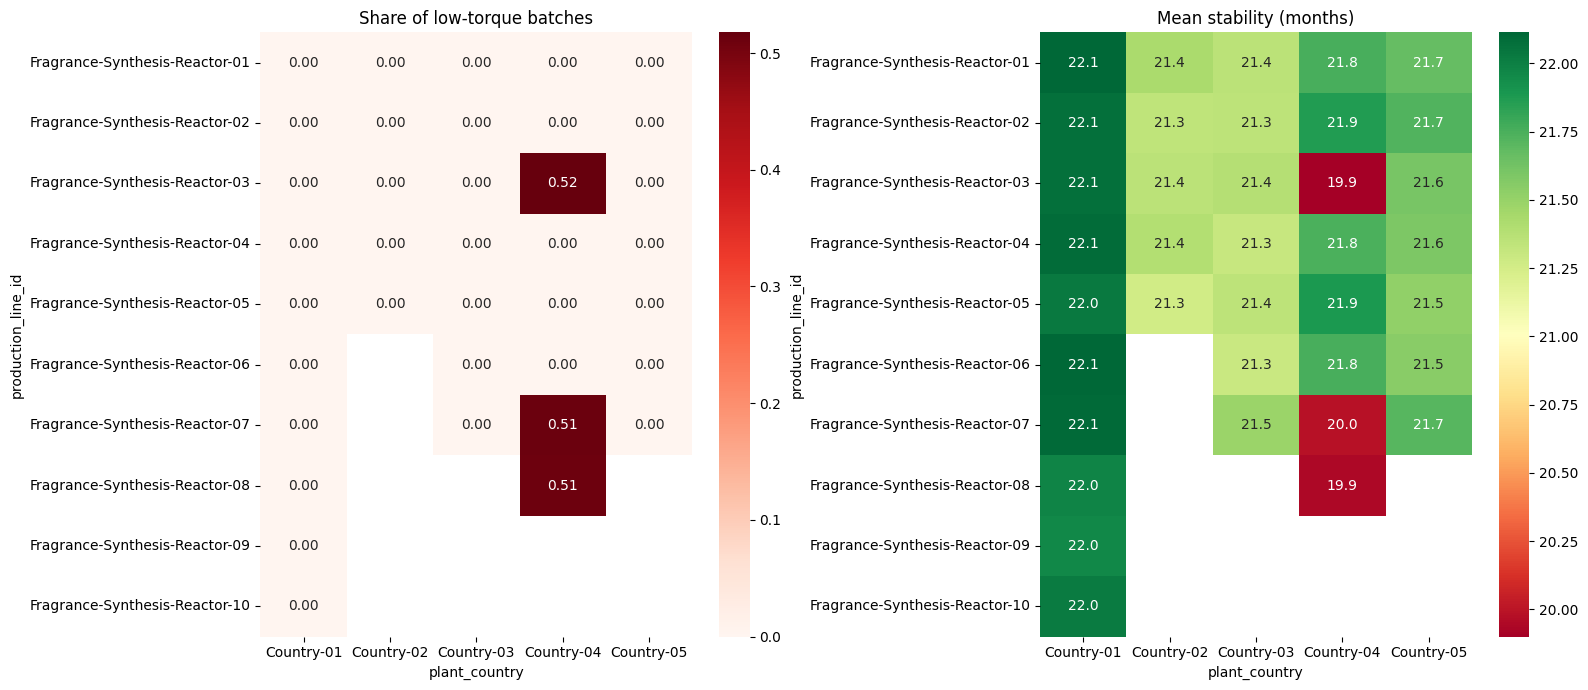

In [17]:
print('Stability by plant:')
print(raw_data.groupby('plant_country')['stability_months'].agg(['mean', 'median', 'count']).round(2))

low_torque_plant_reactor = pd.crosstab(raw_data['production_line_id'], raw_data['plant_country'],
                                       values=raw_data['low_torque'], aggfunc='mean')
stability_plant_reactor = pd.crosstab(raw_data['production_line_id'], raw_data['plant_country'],
                                      values=raw_data['stability_months'], aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(low_torque_plant_reactor, annot=True, fmt='.2f', cmap='Reds', ax=axes[0])
axes[0].set_title('Share of low-torque batches')
sns.heatmap(stability_plant_reactor, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1])
axes[1].set_title('Mean stability (months)')
plt.tight_layout()
plt.show()

In [18]:
#Mean temperature and torque by plant
print(in_range_data.groupby('plant_country')[['reaction_temperature_celsius', 'mixing_torque_nm', 'stability_months']].mean().round(2))

               reaction_temperature_celsius  mixing_torque_nm  \
plant_country                                                   
Country-01                            85.43             12.02   
Country-02                            86.68             11.97   
Country-03                            86.34             11.96   
Country-04                            85.73             11.73   
Country-05                            86.07             11.99   

               stability_months  
plant_country                    
Country-01                22.00  
Country-02                21.43  
Country-03                21.41  
Country-04                21.07  
Country-05                21.63  


The low-torque batches exist in **one plant only: Plant-04, reactors 03, 07 and 08**. The same reactor ids in other plants are at 0%. Those three cells lose about 2 months of mean stability compared with the same reactors elsewhere.

Plant-01 has the best stability overall, and it also runs about 1 °C cooler than the other plants, which matches the negative temperature correlation.

## 7. When did it start?

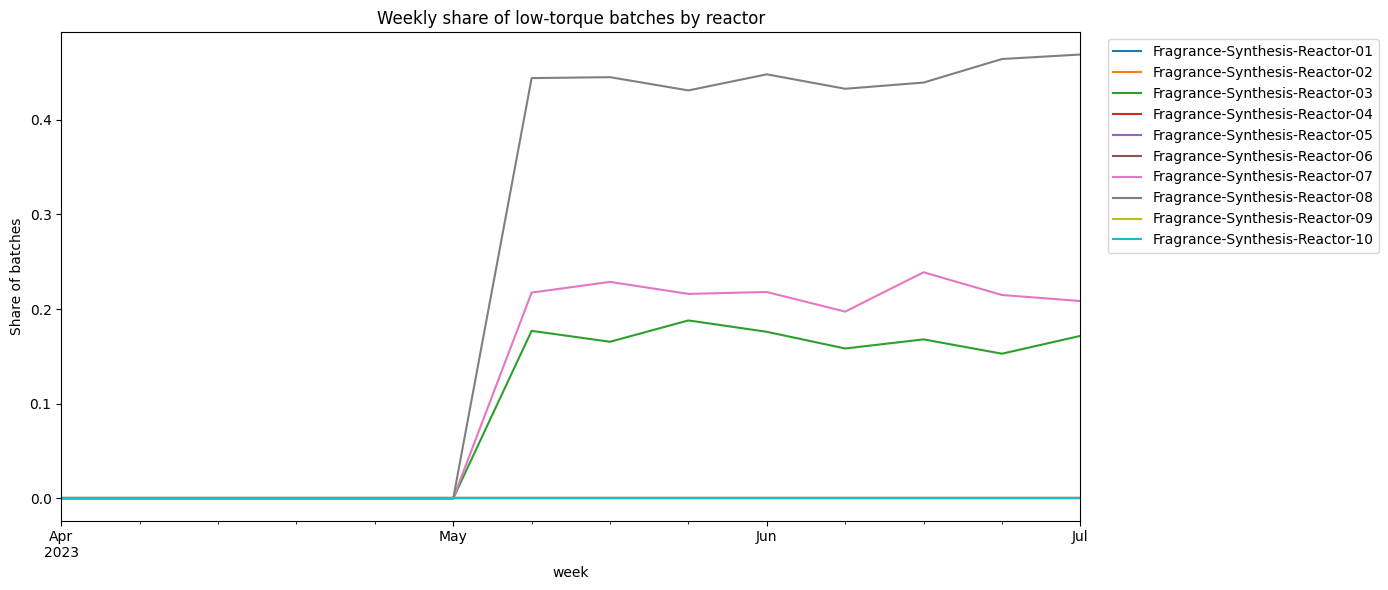

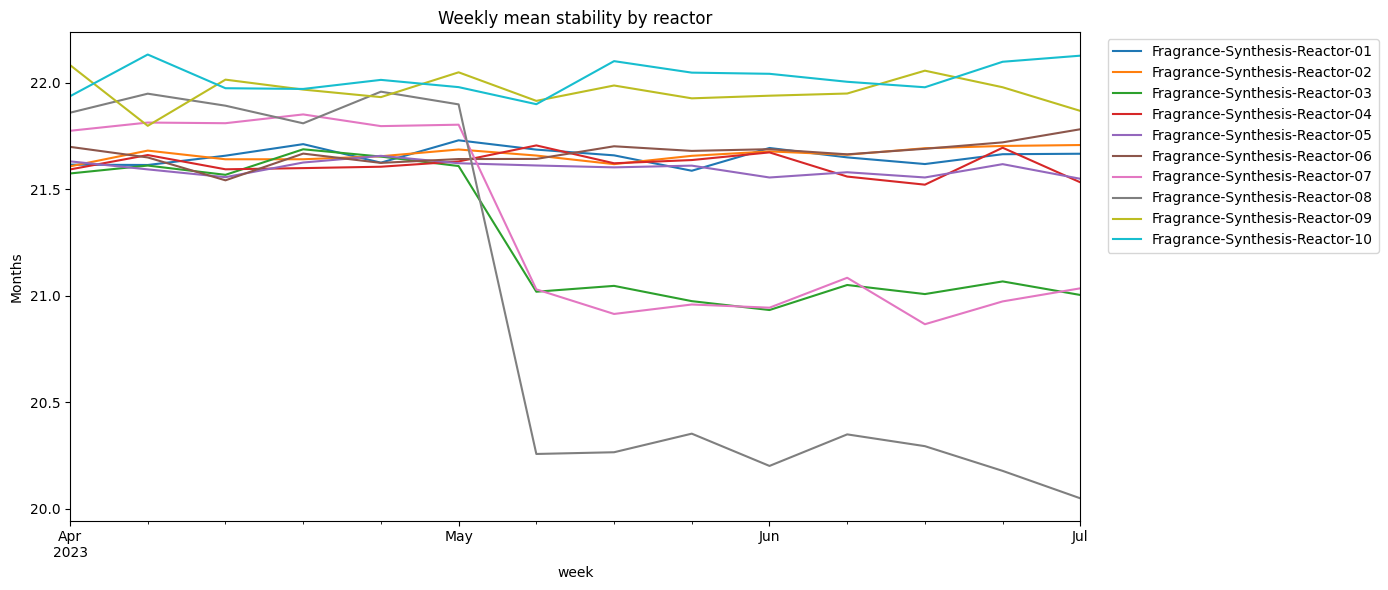

In [19]:
raw_data['week'] = raw_data['event_timestamp'].dt.to_period('W')

weekly_low_torque = raw_data.groupby(['week', 'production_line_id'])['low_torque'].mean().unstack()
weekly_low_torque.plot(figsize=(14, 6))
plt.title('Weekly share of low-torque batches by reactor')
plt.ylabel('Share of batches')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

weekly_stability = raw_data.groupby(['week', 'production_line_id'])['stability_months'].mean().unstack()
weekly_stability.plot(figsize=(14, 6))
plt.title('Weekly mean stability by reactor')
plt.ylabel('Months')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

First low-torque batch in Plant-04: 2023-05-08 00:00:00
production_line_id
Fragrance-Synthesis-Reactor-03   2023-05-08
Fragrance-Synthesis-Reactor-07   2023-05-08
Fragrance-Synthesis-Reactor-08   2023-05-08
Name: event_timestamp, dtype: datetime64[ns]


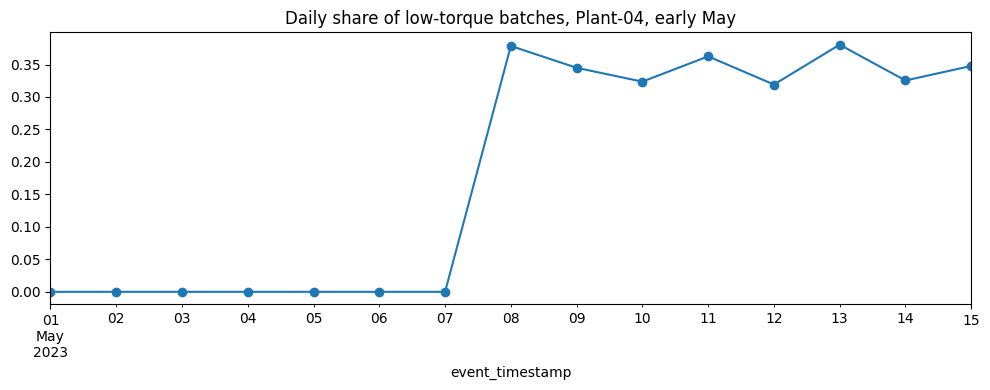

In [20]:
#Exact start date in Plant-04
plant04 = raw_data[raw_data['plant_country'] == 'Country-04']
plant04_low = plant04[plant04['low_torque']]
print('First low-torque batch in Plant-04:', plant04_low['event_timestamp'].min())
print(plant04_low.groupby('production_line_id')['event_timestamp'].min())

daily = plant04.set_index('event_timestamp').resample('D')['low_torque'].mean()
daily.loc['2023-05-01':'2023-05-15'].plot(figsize=(10, 4), marker='o')
plt.title('Daily share of low-torque batches, Plant-04, early May')
plt.tight_layout()
plt.show()

In [21]:
#Do the low-torque batches differ on anything else, or only on torque?
#Using a copy with the fault codes removed so they do not distort the means
fault_codes = {'reaction_temperature_celsius': 210, 'vessel_pressure_bar': -1,
               'density_g_cm3': 860, 'ph_level': 14}
clean_copy = raw_data.copy()
for col, code in fault_codes.items():
    clean_copy.loc[clean_copy[col].round(2) == code, col] = np.nan

affected = clean_copy[(clean_copy['plant_country'] == 'Country-04') &
                      (clean_copy['production_line_id'].isin(['Fragrance-Synthesis-Reactor-03',
                                                              'Fragrance-Synthesis-Reactor-07',
                                                              'Fragrance-Synthesis-Reactor-08']))]
print('Sensor means, low torque vs normal (Plant-04, reactors 03/07/08):')
print(affected.groupby('low_torque')[num_cols].mean().round(3).T)

Sensor means, low torque vs normal (Plant-04, reactors 03/07/08):
low_torque                      False    True 
reaction_temperature_celsius   85.677   85.730
vessel_pressure_bar             2.299    2.295
refractive_index                1.461    1.461
density_g_cm3                   0.860    0.864
ph_level                        5.490    5.575
mixing_torque_nm               11.990   10.788
mass_flow_rate_kg_h           451.036  451.108
stability_months               21.402   18.560


Zero low-torque batches until 7 May 2023, then ~35% of all Plant-04 batches from **8 May 2023** on all three reactors at once (about 9 out of 10 batches inside those three reactors). A single date on three units points to something done to the plant that day, it could be maintance, a recipe change, a new operator, etc.. Its not a random event that occured in one reactor at a time.

Between the two populations, torque is the only sensor that changed. Temperature, pressure, refractive index, density, pH and flow are the same.

## 8. Sensor fault codes

reaction_temperature_celsius == 210: 526 rows, by plant: {'Country-04': 526}
vessel_pressure_bar == -1: 544 rows, by plant: {'Country-04': 544}
density_g_cm3 == 860: 558 rows, by plant: {'Country-04': 558}
ph_level == 14: 543 rows, by plant: {'Country-04': 543}

Share of batches with a fault code by reactor (Plant-04):
production_line_id
Fragrance-Synthesis-Reactor-01    0.034
Fragrance-Synthesis-Reactor-02    0.040
Fragrance-Synthesis-Reactor-03    0.036
Fragrance-Synthesis-Reactor-04    0.039
Fragrance-Synthesis-Reactor-05    0.039
Fragrance-Synthesis-Reactor-06    0.039
Fragrance-Synthesis-Reactor-07    0.040
Fragrance-Synthesis-Reactor-08    0.037
Name: has_fault_code, dtype: float64


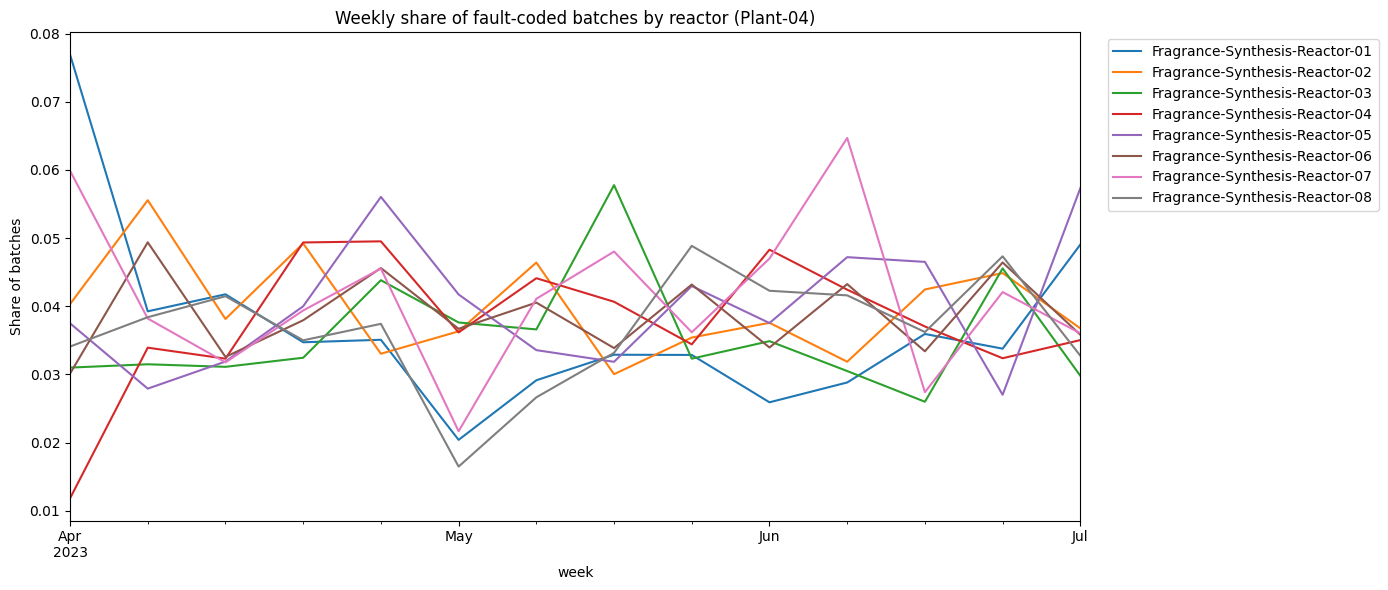

In [22]:
raw_data['has_fault_code'] = False
for col, code in fault_codes.items():
    mask = raw_data[col].round(2) == code
    raw_data['has_fault_code'] = raw_data['has_fault_code'] | mask
    print(f'{col} == {code}: {mask.sum()} rows, by plant:', raw_data.loc[mask, 'plant_country'].value_counts().to_dict())

plant04 = raw_data[raw_data['plant_country'] == 'Country-04']
print('\nShare of batches with a fault code by reactor (Plant-04):')
print(plant04.groupby('production_line_id')['has_fault_code'].mean().round(3))

plant04.groupby(['week', 'production_line_id'])['has_fault_code'].mean().unstack().plot(figsize=(14, 6))
plt.title('Weekly share of fault-coded batches by reactor (Plant-04)')
plt.ylabel('Share of batches')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

All fault codes come from Plant-04, but they are spread over all eight of its reactors at a constant 3-5% since the start of the data, with no change on 8 May. This is a separate data-logging problem, unrelated to the torque event, and it has no effect on stability.

## 9. Conclusions

**Root cause of the reduced stability**
- From **8 May 2023**, reactors **03, 07 and 08 in Plant-04** run most of their batches at a mixing torque of 10-11.4 N·m instead of the normal 11.5-12.5 N·m. No other sensor changed.
- Those batches have a mean stability of **18.6 months vs 21.4** for normal batches in the same reactors, and sit on the 18-month floor.
- The same reactor ids in other plants are unaffected, so the cause is local to Plant-04. The data dates and locates the change but cannot say what was done.

**General drivers of stability (all plants)**
- Mixing torque (+0.68 correlation): better mixing, longer shelf-life.
- Reaction temperature (-0.39): hotter batches age faster. Plant-01 runs ~1 °C cooler and has the best stability.
- Refractive index (+0.13), weak.
- Pressure, density, pH and flow show no linear relationship.

**Data quality**
- ~9% of sensor readings missing at random.
- 1,506 temperature readings logged in Fahrenheit.
- ~2,200 fixed fault codes (210 °C, -1 bar, 860 g/cm³, pH 14), all from Plant-04, constant over time, all reactors.
- Real spread of pH, torque, flow and pressure goes slightly past the normal ranges.
- `purity_grade` and `oxidation_risk_flag` are derived from the target and are not used as inputs.